# Fine-tuning RWKV-7 World 1.5B on GSM8K with LoRA: does an RNN benefit the same way?

**Question this notebook answers:** the sibling notebook,
[fine_tune_qwen_gsm8k_lora.ipynb](fine_tune_qwen_gsm8k_lora.ipynb), LoRA fine-tunes a
**transformer** (`Qwen2.5-1.5B-Instruct`) on GSM8K and finds that its accuracy on held-out test
problems *drops* -- 68.0% to 46.5% on 400 test problems -- because training on GSM8K's terse gold
rationales teaches the model to cut its own chain-of-thought short (mean generation length
275 -> 86 tokens). This notebook asks the same question of a **recurrent** architecture,
RWKV-7 World 1.5B: does the same experiment, run the same way, produce the same failure mode --
or does an RNN's very different internal mechanism (a fixed-size recurrent state instead of a
growing attention window) behave differently under the same fine-tuning pressure?

**Method, in one paragraph, deliberately identical to the sibling notebook's:** load the base
model once; score it, pristine, on 400 held-out GSM8K test problems it has never trained on;
LoRA fine-tune on the official GSM8K training split; reload the adapter *from disk* (not
the in-memory trained object) and score the same 400 problems again; compare with paired
statistics (Wilson confidence intervals, an exact McNemar test), because both models answer the
exact same questions. Overfitting is watched directly via the train/dev loss curve, not inferred
after the fact.

**One important asymmetry with the Qwen run, stated up front:** `Qwen2.5-1.5B-Instruct` was
already instruction-tuned and already a capable reasoner (68% baseline) before that notebook
touched it, so its fine-tuning run had nowhere to go but sideways or down. RWKV-7 World 1.5B is a
**base** model -- pretrained on raw text, never instruction-tuned, never taught this
`#### <number>` answer format. Its baseline on this exact harness is expected to be far lower, so
there is genuine headroom for LoRA fine-tuning to help. A flat-or-negative result here would
therefore be a more surprising finding than it was for Qwen; a real gain would be the expected,
mundane outcome.

**Runs on Colab or locally.** Every path and hyperparameter lives in one Configuration cell;
Colab is detected automatically, Drive is mounted for persistent storage, and the local branch
targets this repo's `models/` directory instead. The fine-tuned model is saved three ways: the
LoRA adapter (~40 MB), an optional standalone merged model, and -- on Colab -- a copy of both
under Google Drive so nothing is lost when the runtime recycles.


## 1. Environment

RWKV-7's HuggingFace port depends on [flash-linear-attention](https://github.com/fla-org/flash-linear-attention)
for its actual forward/backward kernels, which are written in [Triton](https://github.com/triton-lang/triton)
and require **bf16**, which in turn requires an Ampere-or-newer GPU (compute capability >= 8.0:
L4, A100, H100, RTX 30xx/40xx/50xx). Unlike the sibling Qwen notebook -- which auto-selects
bf16-or-fp16 depending on what the GPU supports -- there is no fallback path here: no Triton means
no RWKV-7 kernels means nothing in this notebook runs. This is checked here, first, using only
`torch` (already present in the Colab runtime and in this repo's local `.venv` -- see
[CLAUDE.md](CLAUDE.md)), before Section 2 spends time installing anything else. In particular,
Colab's free-tier **T4 does not qualify** (Turing, no bf16) -- this needs a paid-tier GPU (L4 or
better) on Colab, or an Ampere-or-newer GPU locally.


In [59]:
import sys, platform

IN_COLAB = "google.colab" in sys.modules
print("Running in Colab:", IN_COLAB)
print("Platform:", platform.system(), platform.release())

import torch

assert torch.cuda.is_available(), (
    "No CUDA device visible to torch. On Colab: Runtime -> Change runtime type -> GPU. "
    "Locally: install a CUDA-enabled torch build for your GPU."
)

device_name = torch.cuda.get_device_name(0)
capability = torch.cuda.get_device_capability(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9

print(f"\ntorch:              {torch.__version__}")
print(f"GPU:                {device_name}")
print(f"Compute capability: {capability[0]}.{capability[1]}")
print(f"VRAM:               {vram_gb:.1f} GB")

assert capability >= (8, 0), (
    f"{device_name} is compute capability {capability[0]}.{capability[1]}, but RWKV-7's "
    "flash-linear-attention backend requires bf16 support (Ampere / sm_80 or newer -- e.g. "
    "L4, A100, RTX 30xx/40xx). A T4 (sm_75, Colab's free tier) will NOT work. On Colab: "
    "Runtime -> Change runtime type -> pick a GPU other than T4 (needs a paid tier). "
    "Locally: this needs an RTX 30-series GPU or newer."
)
print("\nGPU check passed -- bf16-capable, RWKV-7 can run here.")


Running in Colab: False
Platform: Windows 11

torch:              2.13.0+cu132
GPU:                NVIDIA GeForce RTX 3080 Ti Laptop GPU
Compute capability: 8.6
VRAM:               17.2 GB

GPU check passed -- bf16-capable, RWKV-7 can run here.


## 2. Dependencies

`flash-linear-attention` supplies RWKV-7's actual kernels; the model repo's `modeling_rwkv7.py`
is a ~150-byte shim that imports from whatever version is installed via `trust_remote_code=True`
(so this notebook runs current library code, not code frozen at some old commit).
`peft`/`transformers`/`datasets`/`accelerate` mirror the sibling Qwen notebook. Notably absent,
for the same reasons as there: `bitsandbytes` (bf16 fits this 1.5B model comfortably -- see
Configuration) and `trl` (training examples are built and loss-masked by hand -- see
Section 12 -- keeping the exact training string visible rather than hidden inside a framework).

**Triton on Windows** ships no official wheel; `triton-windows` is the community port that makes
it work there. Colab and any Linux runtime get ordinary `triton` transitively through
`flash-linear-attention`'s own dependencies, so this only runs on local Windows.


In [60]:
if platform.system() == "Windows" and not IN_COLAB:
    %pip install -q -U triton-windows
else:
    print("Not on local Windows -- triton comes in transitively with flash-linear-attention.")


Note: you may need to restart the kernel to use updated packages.


In [61]:
%pip install -q -U "transformers>=4.48.0" "flash-linear-attention>=0.5.2" peft datasets accelerate matplotlib


Note: you may need to restart the kernel to use updated packages.


## 3. Triton capability probe

A GPU that passes Section 1's compute-capability check can still fail to actually *run* Triton --
a broken local toolchain (no working C compiler for `triton-windows`'s JIT cache, a driver/CUDA
mismatch, etc.) surfaces here in seconds, by compiling and running one trivial kernel, rather than
after 20+ minutes of model loading and generation deep inside the notebook. This is the same
philosophy as the sibling notebook's early hard asserts: fail fast, fail with a clear message.


In [62]:
import triton
import triton.language as tl


@triton.jit
def _add_kernel(x_ptr, y_ptr, out_ptr, n, BLOCK: tl.constexpr):
    pid = tl.program_id(0)
    offs = pid * BLOCK + tl.arange(0, BLOCK)
    mask = offs < n
    x = tl.load(x_ptr + offs, mask=mask)
    y = tl.load(y_ptr + offs, mask=mask)
    tl.store(out_ptr + offs, x + y, mask=mask)


try:
    _n = 1024
    _x = torch.randn(_n, device="cuda")
    _y = torch.randn(_n, device="cuda")
    _out = torch.empty_like(_x)
    _add_kernel[(triton.cdiv(_n, 256),)](_x, _y, _out, _n, BLOCK=256)
    torch.cuda.synchronize()
    assert torch.allclose(_out, _x + _y, atol=1e-5), "kernel ran but produced the wrong output"
    print(f"Triton {triton.__version__}: JIT-compiled and ran a real kernel on "
          f"{torch.cuda.get_device_name(0)}. OK.")
except Exception as e:
    print("Triton failed to compile/run a kernel -- flash-linear-attention (and this whole")
    print("notebook) cannot run here. Cause:")
    print(f"  {type(e).__name__}: {e}")
    print("\nFixes, in order of least effort:")
    print("  1. Colab: switch Runtime -> Change runtime type to a GPU other than T4.")
    print("  2. Local Windows: triton-windows needs a working MSVC or TinyCC toolchain;")
    print("     consider running this notebook from WSL2 (Ubuntu) instead, where ordinary")
    print("     Linux `triton` just works with no extra setup.")
    print("  3. Local Linux: `pip install -U triton` and retry.")
    raise


Triton 3.7.1: JIT-compiled and ran a real kernel on NVIDIA GeForce RTX 3080 Ti Laptop GPU. OK.


## 4. Imports


In [63]:
import os, re, json, math, time, gc

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
# Same rationale as the sibling Qwen notebook: reduces allocator fragmentation,
# must be set before CUDA initializes anything.

from decimal import Decimal, InvalidOperation

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset, Dataset
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    set_seed,
)
from peft import LoraConfig, get_peft_model, PeftModel, TaskType


def gpu_mem():
    return (f"{torch.cuda.memory_allocated()/1e9:.2f} GB allocated / "
            f"{torch.cuda.memory_reserved()/1e9:.2f} GB reserved")


print(f"Memory: {gpu_mem()}")


Memory: 6.30 GB allocated / 8.00 GB reserved


## 5. Configuration

Every path and hyperparameter lives here, in one place, exactly like the sibling notebook's
Section 3 -- a re-run with different settings never means hunting through the rest of the file.


In [64]:
SMOKE = False
# True -> a tiny end-to-end run (a few dozen examples, a handful of training steps) that
# exercises every cell in a few minutes, to catch a broken cell before committing to a real
# run. The accuracy numbers it produces are meaningless (too few examples) -- it only proves
# the plumbing works. Flip back to False for a real run.

SEED = 0
BASE_MODEL_ID = "RWKV/RWKV7-Goose-World3-1.5B-HF"
# The HF-format conversion of the exact checkpoint requested
# (BlinkDL/rwkv-7-world's RWKV-x070-World-1.5B-v3-20250127-ctx4096.pth): its model.safetensors
# is 3,054,894,936 bytes against that .pth's 3,055,062,345 bytes -- same fp16 weights, different
# container. The .pth itself cannot be used directly: the `rwkv` pip package that loads it
# (see rnn_llm_analysis.ipynb) is inference-only -- torch.jit modules and hand-written CUDA
# kernels with no autograd path -- so PEFT cannot attach a trainable LoRA adapter to it. This
# HF port is a real port of the same weights, not a different model, backed by
# flash-linear-attention for its forward/backward kernels.

N_VAL  = 16 if SMOKE else 400    # held out from *train*, used only for the eval-loss curve
N_EVAL = 16 if SMOKE else 400    # drawn from the official *test* split -- the headline comparison
# Same sizing as the sibling Qwen notebook and for the same reason: at n=200 the 95% Wilson
# interval on accuracy is several points wide and the paired McNemar test cannot resolve a
# difference smaller than ~12pp. At n=400 those tighten substantially. Section 7 asserts
# dev/train/test stay disjoint.
N_TRAIN_CAP = 64 if SMOKE else None
# Cap on training examples; None means the entire train split after the dev holdout
# (7,473 - N_VAL = 7,073). The first full run of this notebook capped this at 2,000, and its
# dev-loss curve bottomed out at step 220 of 500 -- under a single pass -- and then turned
# upward, so the cap was plausibly the binding constraint rather than the model's capacity.
# At the effective batch size below, the uncapped split is 885 optimizer steps per epoch;
# early stopping on dev loss decides where the run actually ends.

EPOCHS = 1 if SMOKE else 2
# Two passes over the uncapped train split = 1,770 optimizer steps (see GRAD_ACCUM below) --
# an upper bound rather than a target, since early stopping on dev loss will almost certainly
# halt first. Budgeting a second epoch is still worth it: it gives the loss curve room to show
# (or not show) divergence, the overfitting signal Section 19's plot is built around.
LEARNING_RATE = 1e-4
# The sibling Qwen notebook uses 2e-5 specifically to minimize weight drift, because that model
# already reasoned well and any further training could only make it imitate GSM8K's terser
# gold style instead. RWKV-7 World 1.5B is a *base* model that has never seen this answer
# format at all, so the situation is reversed: there is real headroom for fine-tuning to help,
# and 1e-4 (5x higher) is standard LoRA territory for teaching a new behavior rather than a
# defensive minimum. If `mean new tokens` / `mean reasoning lines` in Section 18 show the same
# collapse pattern anyway, halving this (or LORA_ALPHA) is the first thing to try -- see the
# Conclusion.
BATCH_SIZE = 2
GRAD_ACCUM = 4
# Effective batch 2 x 4 = 8, so the uncapped 7,073-example train split is 885 optimizer steps
# per epoch -- the same arithmetic as the sibling notebook, for the same dense-logging reason:
# a smaller effective batch buys a longer, denser x-axis for the loss plot at the same compute.
# Accumulating over several micro-batches does mean Section 14 has to correct how transformers
# normalizes the resulting loss for this particular model; see the comment at that call site.
MAX_LENGTH = 512       # RWKV World's tokenizer; GSM8K prompt+rationale is typically well under this.
MAX_NEW_TOKENS = 512   # generation cap for eval; truncation rate is reported (Section 10), not hidden.
GEN_BATCH_SIZE = 4     # batched greedy-generation batch size; Section 10 empirically checks that
                       # left-padded batches agree with unbatched generation before this is
                       # trusted. 16 failed that check on the first run (5/8 exact agreement):
                       # fla zeroes padded positions in the recurrent update but the channel-mix
                       # token shift still reads across the pad/real boundary, so a long pad
                       # prefix perturbs the first real token. Batches are length-sorted, so a
                       # smaller batch means far less padding inside each one. If 4 still is not
                       # 8/8, drop to 1 -- exactly correct, just slow.

LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.1
LORA_TARGET_MODULES = [
    "r_proj", "k_proj", "v_proj", "o_proj",   # time-mix (RWKV-7's analogue of attention q/k/v/o)
    "key", "value",                            # channel-mix (RWKV-7's analogue of an MLP)
]
# Confirmed against fla's fla/layers/rwkv7.py and fla/models/rwkv7/modeling_rwkv7.py: these are
# plain nn.Linear layers. RWKV-7 also has its OWN low-rank gates as part of the base
# architecture -- w_lora/a_lora/v_lora/g_lora, state-evolution gates, NOT PEFT adapters -- whose
# inner Linears are named e.g. "w_lora.lora.0". PEFT's suffix matching on the names above cannot
# collide with those; Section 13 asserts the resulting trainable-parameter count is sane as a
# second check.

GRAD_CHECKPOINTING = True   # RWKV7PreTrainedModel declares supports_gradient_checkpointing = True.
                            # Same rationale as the sibling notebook: trades ~20-30% more compute
                            # time per step for substantially lower activation memory.

SAVE_MERGED = True   # Section 17's merge_and_unload() writes a standalone ~3GB model that doesn't
                     # need `peft` installed to reload. On by default here (unlike the Qwen
                     # notebook, where it's opt-in) since storing the fine-tuned model was an
                     # explicit goal of this notebook. merge_and_unload() mutates the base model's
                     # layers in place -- Section 17 works from a fresh reload for exactly that
                     # reason, so nothing upstream is affected.

SYSTEM_PROMPT = (
    "You are a careful math assistant. Solve the problem step by step, then "
    "give the final numeric answer on its own last line in exactly this "
    "form:\n#### <number>"
)
# Identical text to the sibling notebook's, so both experiments ask for the same output
# contract. Unlike Qwen's chat template, RWKV World's template (Section 8) has no *implicit*
# default system message to guard against -- if no system message is given, none is rendered
# at all -- but pinning it explicitly still guarantees training and eval share byte-identical
# prompt text through one function, which is the property that actually matters.

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    OUTPUT_ROOT = "/content/drive/MyDrive/algoverse/rwkv7_gsm8k_lora"
else:
    OUTPUT_ROOT = "./models/rwkv7-1.5b-gsm8k-lora"
# Actively mounts Drive on Colab (rather than only using it if already mounted) so the adapter,
# merged model, metrics, and plots all survive past the runtime recycling -- storing the
# fine-tuned model was an explicit goal here.

ADAPTER_DIR = os.path.join(OUTPUT_ROOT, "adapter")
MERGED_DIR  = os.path.join(OUTPUT_ROOT, "merged")
RESULTS_DIR = os.path.join(OUTPUT_ROOT, "results")
for d in (ADAPTER_DIR, MERGED_DIR, RESULTS_DIR):
    os.makedirs(d, exist_ok=True)

set_seed(SEED)
print(f"SMOKE test mode: {SMOKE}")
print(f"Output root:     {OUTPUT_ROOT}")


SMOKE test mode: False
Output root:     ./models/rwkv7-1.5b-gsm8k-lora


## 6. Load the tokenizer and base model -- once

This is the *only* place the base model is loaded. Every section below -- baseline scoring,
LoRA training, and the final post-training scoring -- reuses these same two objects, exactly
like the sibling notebook, so there's no risk of comparing two subtly different model instances.

`trust_remote_code=True` is required: the model repo's `modeling_rwkv7.py` is a thin shim that
imports the real implementation from the installed `flash-linear-attention` package.


In [65]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, trust_remote_code=True)
print(f"pad_token: {tokenizer.pad_token!r} ({tokenizer.pad_token_id})")
print(f"bos_token: {tokenizer.bos_token!r} ({tokenizer.bos_token_id})")
print(f"eos_token: {tokenizer.eos_token!r} ({tokenizer.eos_token_id})")
# RWKV World's tokenizer aliases pad/bos/unk to the SAME token (id 0,
# "<|rwkv_tokenizer_end_of_text|>") -- unlike Qwen's distinct pad/eos, that's just how this
# tokenizer ships. It's harmless for training (label masking covers every pad position
# regardless of what token sits there) and is handled explicitly for generation below.

# eos_token is the two-character string "\n\n" (the chat template's own turn separator, see
# Section 8) rather than a single reserved special token like Qwen's <|im_end|>. Check how it
# actually tokenizes, since batched generation needs one concrete token id to stop each
# sequence on.
_eos_ids = tokenizer("\n\n", add_special_tokens=False)["input_ids"]
print(f'"\\n\\n" encodes to {_eos_ids}')
if len(_eos_ids) == 1 and _eos_ids[0] != tokenizer.pad_token_id:
    STOP_TOKEN_ID = _eos_ids[0]
    print(f"Using token {STOP_TOKEN_ID} as the generation stop id.")
else:
    STOP_TOKEN_ID = tokenizer.eos_token_id
    print(f"'\\n\\n' isn't a single clean token -- falling back to tokenizer.eos_token_id "
          f"({STOP_TOKEN_ID}). generate_batch() in Section 10 also truncates decoded text at "
          "the first literal '\\n\\n' as a second line of defense.")

model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    dtype=torch.bfloat16,
    trust_remote_code=True,
    device_map={"": 0},
)
model.config.use_cache = True

# fla's RWKV7Config defaults use_l2warp=True (an optional BF16-stability regularizer,
# fla/models/rwkv7/configuration_rwkv7.py) -- this checkpoint's config.json predates that
# flag, so the installed fla library's default silently applies. With it on, the loss is
# routed through fla's L2Wrap, a custom autograd.Function whose forward() returns the loss
# tensor completely unchanged (not a clone). transformers.Trainer.compute_loss then does an
# in-place `loss *= loss_scale` on single-GPU runs, which PyTorch's autograd forbids on the
# un-cloned output of a custom Function: "Output 0 of L2Wrap is a view and is being modified
# inplace." Disabling it here, before LoRA is ever attached, removes that code path -- the
# loss becomes a plain, unwrapped CrossEntropyLoss output with no aliasing hazard. The
# trade-off is losing L2Wrap's intended precision-loss mitigation in bf16; the sibling Qwen
# notebook trains without any equivalent regularizer, so this keeps the two comparable.
model.config.use_l2warp = False
print(f"use_l2warp: {model.config.use_l2warp} (disabled -- see comment above)")

n_params = sum(p.numel() for p in model.parameters())
print(f"\nLoaded {BASE_MODEL_ID}: {n_params/1e9:.2f}B parameters ({model.dtype})")
assert 1.4e9 < n_params < 1.7e9, f"expected ~1.52B parameters, got {n_params/1e9:.2f}B -- wrong model?"
print(f"Memory: {gpu_mem()}")

# What LORA_TARGET_MODULES (Section 5) is matched against, printed so the names are visible
# rather than taken on faith.
_base = getattr(model, "model", model)
_layers = getattr(_base, "layers", None)
if _layers is not None:
    print("\nLayer 0 submodules (time-mix + channel-mix):")
    for name, _ in _layers[0].named_modules():
        if name:
            print(f"  {name}")

print("\nGeneration smoke test:")
_probe = tokenizer("The capital of France is", return_tensors="pt").to(model.device)
with torch.inference_mode():
    _out = model.generate(**_probe, max_new_tokens=8, do_sample=False)
print(" ", repr(tokenizer.decode(_out[0][_probe["input_ids"].shape[1]:], skip_special_tokens=True)))


pad_token: '<|rwkv_tokenizer_end_of_text|>' (0)
bos_token: '<|rwkv_tokenizer_end_of_text|>' (0)
eos_token: '\n\n' (65530)
"\n\n" encodes to [65530]
Using token 65530 as the generation stop id.


Loading weights: 100%|██████████| 795/795 [00:01<00:00, 456.75it/s]


use_l2warp: False (disabled -- see comment above)

Loaded RWKV/RWKV7-Goose-World3-1.5B-HF: 1.53B parameters (torch.bfloat16)
Memory: 9.35 GB allocated / 9.72 GB reserved

Layer 0 submodules (time-mix + channel-mix):
  pre_norm
  attn_norm
  attn
  attn.time_shift
  attn.r_proj
  attn.k_proj
  attn.v_proj
  attn.o_proj
  attn.w_lora
  attn.w_lora.activation
  attn.w_lora.lora
  attn.w_lora.lora.0
  attn.w_lora.lora.2
  attn.a_lora
  attn.a_lora.activation
  attn.a_lora.lora
  attn.a_lora.lora.0
  attn.a_lora.lora.2
  attn.g_lora
  attn.g_lora.activation
  attn.g_lora.lora
  attn.g_lora.lora.0
  attn.g_lora.lora.2
  attn.g_norm
  ffn_norm
  ffn
  ffn.time_shift
  ffn.key
  ffn.value

Generation smoke test:
  ' Paris.\nThe capital of France is'


## 7. Data

The **official** GSM8K train and test splits, exactly like the sibling notebook -- not a
hand-rolled slice of train, which would leave the real 1,319-example test split unused. A fixed
seed makes the sampling reproducible.


In [66]:
raw_train = load_dataset("openai/gsm8k", "main", split="train")
raw_test  = load_dataset("openai/gsm8k", "main", split="test")
print(f"Official train split: {len(raw_train)} | Official test split: {len(raw_test)}")

shuffled_train = raw_train.shuffle(seed=SEED)
dev_rows   = shuffled_train.select(range(N_VAL))
train_rows = shuffled_train.select(range(N_VAL, len(shuffled_train)))
if N_TRAIN_CAP is not None:
    train_rows = train_rows.select(range(min(N_TRAIN_CAP, len(train_rows))))

test_rows = raw_test.shuffle(seed=SEED).select(range(min(N_EVAL, len(raw_test))))

# Defensive check: the headline eval set must never share a question with what the model was
# trained on.
assert set(train_rows["question"]).isdisjoint(test_rows["question"])
assert set(dev_rows["question"]).isdisjoint(test_rows["question"])

print(f"train {len(train_rows)} (fine-tuning)")
print(f"dev   {len(dev_rows)} (held out from train, eval-loss curve only)")
print(f"test  {len(test_rows)} (official test split, headline comparison)")

print(f"\n--- sample gold answer ---\n{train_rows[0]['answer']}")


Official train split: 7473 | Official test split: 1319
train 7073 (fine-tuning)
dev   400 (held out from train, eval-loss curve only)
test  400 (official test split, headline comparison)

--- sample gold answer ---
On Tuesday, Adam bought 3 * 15 apples = <<3*15=45>>45 apples.
On Wednesday, Adam bought 4 * 45 apples = <<4*45=180>>180 apples.
Adam bought 15 apples + 45 apples + 180 apples = <<15+45+180=240>>240 apples on the three days.
#### 240


## 8. Prompt format

RWKV World's own chat template renders `System: ... / User: ... / Assistant:` turns separated by
blank lines, prefixed with its BOS token -- structurally different text from Qwen's
`<|im_start|>role\n...<|im_end|>` markers, but serving the identical purpose. As with the sibling
notebook, one function builds every prompt used anywhere in this notebook, so the training prompt
and the eval prompt are identical by construction; there is no separate "training format" that
could silently drift from the "eval format."


In [67]:
def to_chat_example(question: str) -> str:
    """Render one GSM8K question as an RWKV World chat prompt, ready for generation. Reused
    for both training examples (Section 12) and every eval call (Sections 10, 11, 16)."""
    return tokenizer.apply_chat_template(
        [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": question},
        ],
        tokenize=False,
        add_generation_prompt=True,
    )


print("Rendered prompt:")
print(repr(to_chat_example("PROBE")))


Rendered prompt:
'<|rwkv_tokenizer_end_of_text|>System: You are a careful math assistant. Solve the problem step by step, then give the final numeric answer on its own last line in exactly this form:\n#### <number>\n\nUser: PROBE\n\nAssistant:'


## 9. Answer extraction and scoring

Identical harness to the sibling Qwen notebook's Section 7 -- same regexes, same fallback
policy, same self-test -- so the two experiments are scored exactly the same way and their
numbers are directly comparable.


In [68]:
CALC_RE = re.compile(r"<<[^>]*>>")
_NUM = r"-?(?:\d{1,3}(?:,\d{3})+|\d+)(?:\.\d+)?"
HASH_RE = re.compile(r"####\s*\$?\s*(" + _NUM + r")")
NUM_RE  = re.compile(_NUM)


def clean_target(answer: str) -> str:
    """Strip GSM8K's inline <<calculator>> annotations from a training target, e.g.
    '48/2 = <<48/2=24>>24' -> '48/2 = 24'. A dataset-authoring artifact, not something worth
    the model reproducing verbatim; doesn't touch the '#### N' line it surrounds."""
    return CALC_RE.sub("", answer)


def to_decimal(s):
    """Parse a matched number string into a Decimal, tolerating '$', ',', '%', and a trailing
    period."""
    if s is None:
        return None
    s = s.strip().replace(",", "").replace("$", "").replace("%", "").rstrip(".")
    try:
        return Decimal(s)
    except InvalidOperation:
        return None


def extract_gold(answer: str) -> Decimal:
    m = HASH_RE.search(answer)
    assert m is not None, f"gold answer has no '#### N' line: {answer!r}"
    return to_decimal(m.group(1))


def extract_pred(text: str):
    """Pull the model's final numeric answer out of free-form generated text. Primary: the
    LAST '#### N' occurrence (a model that restates the question before answering could
    otherwise match the wrong one). Fallback: the last number anywhere in the text, for
    generations that never emit the '####' marker. Returns (value, method)."""
    hashes = list(HASH_RE.finditer(text))
    if hashes:
        v = to_decimal(hashes[-1].group(1))
        if v is not None:
            return v, "hash"
    nums = NUM_RE.findall(text)
    if nums:
        return to_decimal(nums[-1]), "last_number"
    return None, "none"


def is_correct(pred, gold) -> bool:
    return pred is not None and pred == gold


def n_reasoning_lines(text: str) -> int:
    """Non-empty lines before the first '#### N' -- a proxy for how much reasoning happened
    before the model committed to an answer, and the clearest single indicator of the
    length-collapse failure mode the sibling Qwen notebook suffered (18.5 -> 4.6 lines)."""
    m = HASH_RE.search(text)
    head = text[: m.start()] if m else text
    return sum(1 for line in head.splitlines() if line.strip())


_cases = [
    ("blah blah #### 72", "72"),
    ("The total is $1,080 dollars.\n#### 1,080", "1080"),
    ("#### -5", "-5"),
    ("no marker, but the answer is 42 apples", "42"),
    ("nothing numeric here", None),
]
for text, expected in _cases:
    got, _ = extract_pred(text)
    want = Decimal(expected) if expected is not None else None
    assert got == want, (text, got, want)
print(f"extract_pred self-test passed ({len(_cases)} cases).")

assert all(extract_gold(a) is not None for a in raw_train["answer"][:500]), "unexpected gold format"
print("Gold-answer '#### N' format verified on a sample of the training set.")


extract_pred self-test passed (5 cases).
Gold-answer '#### N' format verified on a sample of the training set.


## 10. Batched generation, the evaluation harness, and a padding-invariance check

`generate_batch` and `evaluate` are structurally the same as the sibling notebook's: sort by
length to minimize padding, left-pad for batched left-to-right decoding, greedy decode, report
accuracy alongside `'####' compliance`, mean new tokens, and mean reasoning lines (the length-
collapse indicators).

**Why the extra check below.** `flash-linear-attention`'s RWKV-7 layer applies the padding mask
to hidden states and to `v` (zeroing them at pad positions), which is exactly right for
*training* (right-padded, with `-100` labels over the padding anyway). For *generation*
(left-padded), the reasoning is that zeroed hidden states keep `k=v=0` through the pad prefix, so
the recurrent state should stay inert there too -- but channel-mix's token-shift at the
pad/real-token boundary is not obviously covered by that masking. Rather than assume it's fine,
this is checked empirically: generate the same prompts batched and one-at-a-time, and compare.


In [69]:
def generate_batch(model, prompts, max_new_tokens=None, batch_size=None):
    """Greedy-decode a batch of prompts. Returns (texts, n_new_tokens), aligned to `prompts`."""
    max_new_tokens = max_new_tokens or MAX_NEW_TOKENS
    batch_size = batch_size or GEN_BATCH_SIZE

    original_side = tokenizer.padding_side
    tokenizer.padding_side = "left"
    model.eval()

    order = sorted(range(len(prompts)), key=lambda i: len(prompts[i]))
    texts = [None] * len(prompts)
    n_new_tokens = [0] * len(prompts)

    try:
        with torch.inference_mode():
            for start in range(0, len(order), batch_size):
                idx = order[start:start + batch_size]
                batch = [prompts[i] for i in idx]
                inputs = tokenizer(batch, return_tensors="pt", padding=True).to(model.device)
                out = model.generate(
                    **inputs,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,   # greedy -> reproducible
                    eos_token_id=[STOP_TOKEN_ID],
                    pad_token_id=tokenizer.pad_token_id,
                )
                new_tokens = out[:, inputs["input_ids"].shape[1]:]
                decoded = tokenizer.batch_decode(new_tokens, skip_special_tokens=True)
                for i, ids, text in zip(idx, new_tokens, decoded):
                    # Second line of defense against an imperfect stop-token resolution
                    # (Section 6): truncate at the template's own turn separator if the model
                    # kept going past it.
                    if "\n\n" in text:
                        text = text[:text.index("\n\n")]
                    texts[i] = text.strip()
                    n_new_tokens[i] = int((ids != tokenizer.pad_token_id).sum())
    finally:
        tokenizer.padding_side = original_side

    return texts, n_new_tokens


def evaluate(model, rows, tag, verbose_examples=3):
    """Score `model` against `rows` (a GSM8K-format dataset slice), using the SAME harness every
    time. Returns one DataFrame row per example."""
    torch.cuda.reset_peak_memory_stats()
    prompts = [to_chat_example(r["question"]) for r in rows]
    t0 = time.time()
    generations, n_new_tokens = generate_batch(model, prompts)
    elapsed = time.time() - t0

    records = []
    for row, gen, ntok in zip(rows, generations, n_new_tokens):
        gold = extract_gold(row["answer"])
        pred, method = extract_pred(gen)
        records.append({
            "question": row["question"],
            "gold": gold,
            "prediction": gen,
            "pred_value": pred,
            "pred_method": method,
            "n_new_tokens": ntok,
            "n_reasoning_lines": n_reasoning_lines(gen),
            "correct": is_correct(pred, gold),
        })
    df = pd.DataFrame(records)
    acc = df["correct"].mean()
    compliance = (df["pred_method"] == "hash").mean()
    print(f"{tag}: {df['correct'].sum()}/{len(df)} correct = {acc:.1%}  |  "
          f"'####' compliance {compliance:.1%}  |  "
          f"mean {df['n_new_tokens'].mean():.0f} new tokens  |  "
          f"mean {df['n_reasoning_lines'].mean():.1f} reasoning lines  |  "
          f"{elapsed:.0f}s ({elapsed/len(df):.2f}s/example)  |  "
          f"peak {torch.cuda.max_memory_allocated()/1e9:.2f} GB")

    for _, r in df.head(verbose_examples).iterrows():
        flag = "correct" if r["correct"] else "wrong"
        print(f"  [{flag}] gold={r['gold']}  pred={r['pred_value']}  (via {r['pred_method']})")

    return df


In [70]:
print("Padding-invariance check: batched generation vs batch_size=1, on 8 probe prompts.\n")
_probe_prompts = [to_chat_example(r["question"]) for r in test_rows.select(range(8))]

_batched_texts, _ = generate_batch(model, _probe_prompts, max_new_tokens=128, batch_size=8)
_solo_texts = []
for p in _probe_prompts:
    t, _ = generate_batch(model, [p], max_new_tokens=128, batch_size=1)
    _solo_texts.append(t[0])

_matches = sum(a == b for a, b in zip(_batched_texts, _solo_texts))
print(f"Exact-string agreement: {_matches}/{len(_probe_prompts)}")
if _matches < len(_probe_prompts):
    print("\nMismatch(es) found -- exactly the failure mode this check exists to catch (see the")
    print("markdown above). If this is below 100%, set GEN_BATCH_SIZE = 1 in Configuration")
    print("(slower, but exactly correct) before trusting any eval number below.")
    for i, (a, b) in enumerate(zip(_batched_texts, _solo_texts)):
        if a != b:
            print(f"\n  [{i}] batched : {a[:80]!r}")
            print(f"       solo    : {b[:80]!r}")
else:
    print("Left-padded batched generation matches unbatched generation exactly --")
    print("GEN_BATCH_SIZE can be trusted for the eval passes below.")


Padding-invariance check: batched generation vs batch_size=1, on 8 probe prompts.

Exact-string agreement: 5/8

Mismatch(es) found -- exactly the failure mode this check exists to catch (see the
markdown above). If this is below 100%, set GEN_BATCH_SIZE = 1 in Configuration
(slower, but exactly correct) before trusting any eval number below.

  [0] batched : 'Carmen has $100, Samantha has $25 more than Carmen, and Daisy has $50 more than '
       solo    : 'Carmen has $100, Samantha has $25 more than Carmen, and Daisy has $50 more than '

  [1] batched : 'The cat eats nine sausages in 30 minutes.\nThe dog can eat the same number of sau'
       solo    : 'The cat eats nine sausages in 30 minutes.\nThe dog can eat the same number of sau'

  [2] batched : "Let's denote the age of Akbar as A, Alessandro as A', Helene as H, and Wilfred a"
       solo    : "Let's denote the age of Akbar as A, Alessandro as A', Helene as H, and Wilfred a"


## 11. Score the pristine base model

Before any adapter exists -- the baseline every later number is measured against.


In [71]:
print("Scoring the PRISTINE base model (no adapter attached) ...\n")
base_df = evaluate(model, test_rows, tag="BASE MODEL (pristine)")
base_acc = base_df["correct"].mean()


Scoring the PRISTINE base model (no adapter attached) ...

BASE MODEL (pristine): 22/400 correct = 5.5%  |  '####' compliance 7.2%  |  mean 511 new tokens  |  mean 34.3 reasoning lines  |  2455s (6.14s/example)  |  peak 9.57 GB
  [correct] gold=400  pred=400  (via last_number)
  [wrong] gold=25  pred=45  (via last_number)
  [wrong] gold=3  pred=2018  (via last_number)


## 12. Build the training set

The prompt portion of each example is masked out of the loss (`-100`) so the model is only ever
trained to predict the answer, never to reproduce the question back -- identical construction to
the sibling notebook's Section 10, including the same token-prefix guard: if the tokenizer ever
merged a token across the prompt/answer boundary, the `-100` mask would silently land on the
wrong tokens, so that possibility is asserted against rather than assumed away.


In [72]:
def build_example(question, answer):
    """Return (input_ids, labels) for one training example."""
    prompt = to_chat_example(question)
    target = clean_target(answer)
    full_text = prompt + target + tokenizer.eos_token

    prompt_ids = tokenizer(prompt, add_special_tokens=False)["input_ids"]
    full_ids = tokenizer(full_text, add_special_tokens=False)["input_ids"][:MAX_LENGTH]

    n_masked = min(len(prompt_ids), len(full_ids))
    labels = [-100] * n_masked + full_ids[n_masked:]
    return full_ids, labels


# Guard: the prompt must be a clean token prefix of the full sequence, or the -100 mask above
# would silently land on the wrong tokens.
_probe_q = train_rows[0]["question"]
_probe_prompt = to_chat_example(_probe_q)
_probe_ids = tokenizer(_probe_prompt, add_special_tokens=False)["input_ids"]
_probe_full = tokenizer(
    _probe_prompt + clean_target(train_rows[0]["answer"]) + tokenizer.eos_token,
    add_special_tokens=False,
)["input_ids"]
assert _probe_full[:len(_probe_ids)] == _probe_ids, (
    "Prompt is not a clean token prefix of the full sequence -- label masking would misalign."
)
print("Prompt/answer token boundary verified clean.")

train_examples = [build_example(r["question"], r["answer"]) for r in train_rows]
dev_examples   = [build_example(r["question"], r["answer"]) for r in dev_rows]

lengths = [len(ids) for ids, _ in train_examples]
print(f"\n{len(train_examples)} training examples | "
      f"length mean {np.mean(lengths):.0f}, p95 {np.percentile(lengths, 95):.0f}, "
      f"max {max(lengths)} tokens (cap {MAX_LENGTH})")


def to_hf_dataset(examples):
    return Dataset.from_dict({
        "input_ids": [ids for ids, _ in examples],
        "labels":    [labels for _, labels in examples],
    })


train_dataset = to_hf_dataset(train_examples)
dev_dataset   = to_hf_dataset(dev_examples)

# Pads each batch to its own longest member (not to MAX_LENGTH), and pads labels with -100 so
# padding never contributes to the loss. Right padding here is exactly correct for an RNN:
# every real token still sees only real tokens before it, and the padding contributes nothing
# to the loss.
data_collator = DataCollatorForSeq2Seq(tokenizer, padding=True, label_pad_token_id=-100)

_ids0, _labels0 = train_examples[0]
_n_masked = sum(1 for l in _labels0 if l == -100)
print(f"\nExample 0: {len(_ids0)} tokens, {_n_masked} masked (prompt), "
      f"{len(_ids0) - _n_masked} supervised (answer)")


Prompt/answer token boundary verified clean.

7073 training examples | length mean 176, p95 271, max 446 tokens (cap 512)

Example 0: 140 tokens, 86 masked (prompt), 54 supervised (answer)


## 13. Attach the LoRA adapter

Targets both time-mix (`r/k/v/o_proj`, RWKV-7's analogue of attention) and channel-mix
(`key`/`value`, its analogue of an MLP) -- see Section 5 for why these names and not the
architecture's own `*_lora` gates.


In [73]:
lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    target_modules=LORA_TARGET_MODULES,
    bias="none",
)

peft_model = get_peft_model(model, lora_config)
peft_model.enable_input_require_grads()
peft_model.print_trainable_parameters()

trainable_dtypes = {p.dtype for p in peft_model.parameters() if p.requires_grad}
print(f"Trainable parameter dtypes: {trainable_dtypes}")
assert trainable_dtypes == {torch.float32}, "expected all trainable (LoRA) params in fp32"

# Sanity check that LORA_TARGET_MODULES matched real Linear layers and not RWKV-7's OWN
# low-rank gates (w_lora/a_lora/v_lora/g_lora -- part of the base architecture, not PEFT
# adapters). If those got wrapped too, PEFT would report far more trainable params than this.
n_trainable = sum(p.numel() for p in peft_model.parameters() if p.requires_grad)
print(f"\n{n_trainable:,} trainable LoRA params "
      f"({100 * n_trainable / n_params:.2f}% of the {n_params/1e9:.2f}B base)")


trainable params: 14,155,776 || all params: 1,541,560,320 || trainable%: 0.9183
Trainable parameter dtypes: {torch.float32}

14,155,776 trainable LoRA params (0.93% of the 1.53B base)


### A note on saving: two upstream quirks this notebook works around

`save_pretrained()` does not, by itself, produce a reloadable directory for this model,
for two independent reasons -- both worked around by the `finalize_save_dir()` helper
below, which every save in this notebook runs afterwards.

**The tokenizer's save and load disagree.** `hf_rwkv_tokenizer.py` looks for
`rwkv_vocab_v20230424.txt` when loading, but its `save_vocabulary()` writes `vocab.txt` --
and in a different format: the loader parses `<index> <repr> <length>` per line, while the
writer emits just the bare token. Its own output is therefore unreadable by its own
loader, and `from_pretrained` ends up passing `vocab_file=None` into the constructor
(`TypeError: isfile: path should be string, bytes, os.PathLike or integer, not NoneType`).
Since fine-tuning never changes the vocabulary, the fix is to copy the *original* vocab
file in under the name the loader expects, and delete the malformed one.

**The merged model's custom code is only half-copied.** Saving copies
`configuration_rwkv7.py` but not `modeling_rwkv7.py`, even though `config.json`'s
`auto_map` still points `AutoModel`/`AutoModelForCausalLM` at `modeling_rwkv7.*`. The
helper writes back the same four-line shim the upstream repo ships, which re-exports the
classes from the installed `flash-linear-attention`.


In [74]:
import shutil
from huggingface_hub import hf_hub_download

# The upstream HF repo's modeling_rwkv7.py is a 4-line shim re-exporting the real classes
# from the installed flash-linear-attention package. save_pretrained doesn't copy it.
_MODELING_SHIM = (
    "from fla.models.rwkv7 import RWKV7ForCausalLM, RWKV7Model, RWKV7Config\n"
    "RWKV7ForCausalLM = RWKV7ForCausalLM\n"
    "RWKV7Model = RWKV7Model\n"
    "RWKV7Config = RWKV7Config\n"
)


def finalize_save_dir(save_dir, is_model_dir=False):
    """Make a save_pretrained() output actually reloadable. See the markdown above."""
    vocab_name = type(tokenizer).vocab_files_names["vocab_file"]

    target = os.path.join(save_dir, vocab_name)
    if not os.path.exists(target):
        shutil.copyfile(hf_hub_download(BASE_MODEL_ID, vocab_name), target)

    bogus = os.path.join(save_dir, "vocab.txt")
    if os.path.exists(bogus):
        os.remove(bogus)   # unparseable by the loader; a trap if left in place

    if is_model_dir:
        cfg_path = os.path.join(save_dir, "config.json")
        auto_map = {}
        if os.path.exists(cfg_path):
            with open(cfg_path, encoding="utf-8") as f:
                auto_map = json.load(f).get("auto_map", {})
        for module_name in sorted({v.split(".")[0] for v in auto_map.values()}):
            path = os.path.join(save_dir, f"{module_name}.py")
            if not os.path.exists(path) and module_name == "modeling_rwkv7":
                with open(path, "w", encoding="utf-8") as f:
                    f.write(_MODELING_SHIM)

    # Prove it: the directory must round-trip through AutoTokenizer.
    _check = AutoTokenizer.from_pretrained(save_dir, trust_remote_code=True)
    assert _check("probe", add_special_tokens=False)["input_ids"], "tokenizer reload failed"
    return save_dir


## 14. Train

**Logging cadence**, identical to the sibling notebook: training loss logged at *every*
optimizer step (`logging_steps=1`), dev loss evaluated ~25 times across the run with
`eval_on_start=True` adding a step-0 anchor before any weight has moved. Each train-loss point is
a single 8-example batch, so the raw series is genuinely noisy -- Section 19 plots both the raw
points and a rolling mean rather than hiding that. `load_best_model_at_end` restores whichever
checkpoint had the lowest dev loss; `EarlyStoppingCallback` is given a deliberately **loose**
patience (about a quarter of the run) so the full two-epoch curve gets drawn rather than halting
right as the second epoch starts to diverge -- `load_best_model_at_end` restores the best
checkpoint regardless, so running longer costs accuracy nothing, only time.

**One setting worth calling out, and one bug this run surfaced.**
`per_device_eval_batch_size` is left equal to `BATCH_SIZE` and `prediction_loss_only=True`
is set -- unlike the sibling Qwen notebook, this checkpoint's config does *not* set
`fuse_linear_cross_entropy`, so `logits` **are** computed on every forward pass (a
`[batch, seq, 65536]` tensor); without `prediction_loss_only=True`, `Trainer`'s eval loop
would gather that full tensor across all `N_VAL` dev examples, which is exactly the kind
of eval-memory spike the sibling notebook had to fight directly.

Separately, this checkpoint's `RWKV7Config` defaults `use_l2warp=True` -- an optional
regularizer (`fla`'s `L2Wrap`) meant to curb overconfidence and bf16 precision loss. Its
`forward()` returns the loss tensor completely unmodified, and `Trainer.compute_loss`
later multiplies that tensor in place (`loss *= loss_scale`) on single-GPU runs -- a
combination PyTorch's autograd forbids ("Output 0 of L2Wrap is a view and is being
modified inplace"), since the un-cloned output of a custom `autograd.Function` can't
safely be mutated afterward. Section 6 disables `use_l2warp` right after the model loads,
before LoRA is ever attached, which removes that code path entirely. The trade-off is
losing L2Wrap's bf16-stability nudge; the sibling Qwen notebook trains without an
equivalent regularizer either, so this keeps the two comparable.

A second, unrelated mismatch shows up the same way: `RWKV7ForCausalLM.forward` declares
both a `labels` parameter and an optional `shift_labels` parameter (the model derives the
latter from the former when it's omitted). `transformers`' automatic label-detection
(`find_labels`) matches on any parameter name containing "label", so it treats *both* as
required -- and `Trainer`'s evaluation loop refuses to compute a loss at all unless every
detected label name is present in the batch. Our batches only ever contain `labels`, so
without an override, evaluation silently produces zero loss values (only training is
unaffected, since it never consults this list) -- surfacing later as
`KeyError: 'eval_loss'` when checkpoint selection tries to read a metric that was never
computed. `label_names=["labels"]` in the training arguments below pins the correct list
directly, which is the documented way to override the automatic detection.

A third mismatch, and the only one of the three that affects the optimizer rather than just
a log line: `transformers` decides whether to divide the accumulated loss by
`gradient_accumulation_steps` by inspecting the model's `forward` signature. A model taking
`**kwargs` is assumed to accept `num_items_in_batch` and normalize its own loss by it, so
`Trainer` skips its own division. `RWKV7ForCausalLM` does take `**kwargs` -- but it ignores
`num_items_in_batch`, forwarding it into the inner model where it is dropped, and returns a
plain mean-reduction cross-entropy per micro-batch. Accelerate does not compensate either:
`Trainer` pins the `Accelerator`'s own accumulation count to 1 precisely so that nothing
divides twice. Left alone, gradients accumulate `GRAD_ACCUM` times too large. The first full
run of this notebook shows why that is not merely cosmetic: with `max_grad_norm` at its default
of 1.0, **every one of its 340 steps was clipped** -- median gradient norm 5.4, maximum 23.3 --
so the clip, by a factor that varied step to step between roughly 3x and 23x, set the size of
every update instead of the cosine learning-rate schedule, and AdamW's moment estimates were
fed inconsistently-scaled gradients throughout. `trainer.model_accepts_loss_kwargs = False`
below restores the division. A useful side effect: the training-loss column becomes directly
comparable to the dev-loss column again -- before the fix it read `GRAD_ACCUM` times higher,
which reads convincingly like a model that never converged.

**The same standing caveat about dev loss applies here too**: it measures how closely the model
imitates GSM8K's terse gold text. For Qwen that was actively the harmful behavior; for a base
model that has no prior CoT style to lose, it matters less, but `mean new tokens` and
`mean reasoning lines` in Section 16's table are still the direct check, not dev loss itself.


In [75]:
gc.collect()
torch.cuda.empty_cache()
print(f"Memory before training: {gpu_mem()}")

effective_batch = BATCH_SIZE * GRAD_ACCUM
steps_per_epoch = max(1, -(-len(train_dataset) // effective_batch))   # ceil division
total_steps = steps_per_epoch * EPOCHS
warmup_steps = max(1, int(0.1 * total_steps))

logging_steps = 1
eval_steps = max(1, total_steps // 25)
early_stopping_patience = max(3, (total_steps // 4) // eval_steps)

print(f"{len(train_dataset)} examples | micro-batch {BATCH_SIZE} x accum {GRAD_ACCUM} "
      f"= effective batch {effective_batch}")
print(f"{total_steps} total steps ({steps_per_epoch}/epoch x {EPOCHS} epochs), {warmup_steps} warmup")
print(f"log every {logging_steps} step -> {total_steps} train-loss points")
print(f"dev eval every {eval_steps} steps -> ~{total_steps // eval_steps + 1} dev-loss points "
      f"({len(dev_dataset)} examples each)")
print(f"early-stopping patience {early_stopping_patience} evals "
      f"(~{early_stopping_patience * eval_steps} steps)\n")

training_args = TrainingArguments(
    output_dir=os.path.join(OUTPUT_ROOT, "checkpoints"),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=GRAD_ACCUM,
    gradient_checkpointing=GRAD_CHECKPOINTING,
    learning_rate=LEARNING_RATE,
    warmup_steps=warmup_steps,
    lr_scheduler_type="cosine",
    logging_steps=logging_steps,
    eval_strategy="steps",
    eval_steps=eval_steps,
    eval_on_start=True,
    save_strategy="steps",
    save_steps=eval_steps,          # must match eval_steps for load_best_model_at_end
    save_total_limit=2,
    save_only_model=True,           # skip the optimizer state per checkpoint
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    prediction_loss_only=True,      # mandatory -- see the markdown above (fuse_cross_entropy)
    label_names=["labels"],
    # RWKV7ForCausalLM.forward has BOTH `labels` and `shift_labels` params (the latter
    # optional, derived internally when omitted). transformers' automatic label-name
    # detection (find_labels) substring-matches "label" against every forward param, so
    # it picks up BOTH names -- and Trainer.prediction_step then requires ALL of them
    # present in a batch before it will compute an eval loss at all. Our batches only
    # ever carry `labels`, so without this override, evaluation silently produces zero
    # loss values (training is unaffected -- it doesn't consult label_names). Pinning
    # label_names here is the documented mechanism for exactly this mismatch.
    bf16=True,                      # required, not auto-selected -- see Section 1
    optim="adamw_torch",
    report_to="none",
    seed=SEED,
    dataloader_drop_last=False,
)

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=dev_dataset,
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=early_stopping_patience)],
)

# --- Gradient-accumulation loss normalization ----------------------------------------
# transformers decides whether to divide the accumulated loss by GRAD_ACCUM by inspecting the
# model's forward signature: a model taking **kwargs is assumed to accept `num_items_in_batch`
# and normalize its own loss by it, so Trainer skips its own division. RWKV7ForCausalLM does
# take **kwargs -- but it ignores `num_items_in_batch`, forwarding it to the inner model where
# it is dropped, and returns a plain mean-reduction cross-entropy per micro-batch. Accelerate
# does not make up the difference either: Trainer pins the Accelerator's own accumulation count
# to 1 specifically to avoid double-division. Left alone, gradients therefore accumulate
# GRAD_ACCUM times too large -- not merely a cosmetic logging issue, because `max_grad_norm`
# (1.0 by default) then clips nearly every step by a large, step-varying factor, so the clip
# rather than the LR schedule ends up setting each update's size. Setting this flag False is
# the remedy Trainer.compute_loss's own docstring points to, and restores the division for the
# gradients and the logged loss alike.
trainer.model_accepts_loss_kwargs = False

# --- Pre-flight: prove the eval path works before committing to a full run -----------
# `metric_for_best_model="eval_loss"` and EarlyStoppingCallback both hard-fail with a bare
# `KeyError: 'eval_loss'` the first time an evaluation runs without producing that metric
# -- which, at eval_steps above, is minutes into training. These two checks cost a couple
# of seconds and turn that into an immediate, explained failure.
assert trainer.label_names == ["labels"], (
    f"trainer.label_names is {trainer.label_names}, expected ['labels'].\n"
    "transformers auto-detects label arguments by substring-matching 'label' against the\n"
    "model's forward signature, which for RWKV7ForCausalLM picks up BOTH `labels` and\n"
    "`shift_labels` -- and then refuses to compute an eval loss unless every detected name\n"
    "is present in each batch. The `label_names=[\"labels\"]` argument above prevents that.\n"
    "If this assertion fires, that argument is not in the code that actually ran: your\n"
    "editor is executing a stale copy of this cell. Close and reopen the notebook, then\n"
    "re-run this cell."
)

assert trainer.model_accepts_loss_kwargs is False, (
    "trainer.model_accepts_loss_kwargs is True: the gradient-accumulation normalization\n"
    "assignment above did not run, so gradients would accumulate GRAD_ACCUM times too large\n"
    "and max_grad_norm would clip essentially every step. As with the assertion above, this\n"
    "means your editor is executing a stale copy of this cell: close and reopen the notebook."
)

_n_preflight = min(4, len(dev_dataset))
_preflight = trainer.evaluate(eval_dataset=dev_dataset.select(range(_n_preflight)))
assert "eval_loss" in _preflight, (
    f"Pre-flight evaluation returned no 'eval_loss' (keys: {sorted(_preflight)}).\n"
    "Training would crash at the first scheduled evaluation. Do not start a full run."
)
print(f"Pre-flight eval OK on {_n_preflight} examples -- eval_loss="
      f"{_preflight['eval_loss']:.4f}, so checkpoint selection has the metric it needs.")
# trainer.train() re-initializes trainer.state below, so this pre-flight evaluation does
# not leave a stray point in the Section 19 loss curve.

torch.cuda.reset_peak_memory_stats()

print("Training...")
train_result = trainer.train()

print(f"\nFinal training loss: {train_result.training_loss:.4f}")
print(f"Peak memory: {torch.cuda.max_memory_allocated()/1e9:.2f} GB")


Memory before training: 9.41 GB allocated / 9.60 GB reserved
7073 examples | micro-batch 2 x accum 4 = effective batch 8
1770 total steps (885/epoch x 2 epochs), 177 warmup
log every 1 step -> 1770 train-loss points
dev eval every 70 steps -> ~26 dev-loss points (400 examples each)
early-stopping patience 6 evals (~420 steps)



Training Loss,Validation Loss,Step
No log,1.780926,0


Pre-flight eval OK on 4 examples -- eval_loss=1.7809, so checkpoint selection has the metric it needs.
Training...


Step,Training Loss,Validation Loss
0,No log,1.699042
70,0.692883,0.706367
140,0.747251,0.676037
210,0.630058,0.662309
280,0.831385,0.653865


KeyboardInterrupt: 

## 15. Save the adapter

Saves only the LoRA weights (tens of MB), not the full base model.


In [ ]:
peft_model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)
finalize_save_dir(ADAPTER_DIR)

with open(os.path.join(RESULTS_DIR, "train_log.json"), "w") as f:
    json.dump(trainer.state.log_history, f, indent=2)

print(f"Adapter saved to {ADAPTER_DIR}")
for fname in sorted(os.listdir(ADAPTER_DIR)):
    size = os.path.getsize(os.path.join(ADAPTER_DIR, fname))
    print(f"  {fname:<32} {size/1e6:.2f} MB")


Adapter saved to ./models/rwkv7-1.5b-gsm8k-lora\adapter
  README.md                        0.01 MB
  adapter_config.json              0.00 MB
  adapter_model.safetensors        56.66 MB
  chat_template.jinja              0.00 MB
  hf_rwkv_tokenizer.py             0.01 MB
  tokenizer_config.json            0.00 MB
  vocab.txt                        0.91 MB


## 16. Reload the adapter from disk, verify it round-trips, then score

The model scored here is loaded **from the saved adapter directory**, not the in-memory object
that just finished training -- the reported number reflects the artifact actually saved to disk.
Before trusting that reload, a small self-check: disabling the adapter should reproduce (or very
nearly reproduce) the pristine base model's behavior from Section 11 on the same handful of
prompts.


In [ ]:
gc.collect()
torch.cuda.empty_cache()
peft_model.config.use_cache = True

# Self-check: with the adapter disabled, this should behave like the pristine base model did in
# Section 11. Greedy batched decoding isn't bit-for-bit deterministic across different batch
# compositions (padding changes the order floating-point additions happen in), so we compare
# extracted answers, not raw strings.
_probe_rows = test_rows.select(range(min(8, len(test_rows))))
_probe_prompts = [to_chat_example(r["question"]) for r in _probe_rows]
with peft_model.disable_adapter():
    _check_texts, _ = generate_batch(peft_model, _probe_prompts)
_check_preds = [extract_pred(t)[0] for t in _check_texts]
_base_preds = [extract_pred(t)[0] for t in base_df["prediction"].iloc[:len(_probe_rows)]]
_matches = sum(a == b for a, b in zip(_check_preds, _base_preds))
print(f"Adapter-disabled reproduces base predictions: {_matches}/{len(_probe_rows)}")

if "from_disk" not in peft_model.peft_config:
    peft_model.load_adapter(ADAPTER_DIR, adapter_name="from_disk")
peft_model.set_adapter("from_disk")

print("\nScoring the FINE-TUNED model (adapter reloaded from disk) ...\n")
tuned_df = evaluate(peft_model, test_rows, tag="FINE-TUNED MODEL (from disk)")
tuned_acc = tuned_df["correct"].mean()


Adapter-disabled reproduces base predictions: 7/8

Scoring the FINE-TUNED model (adapter reloaded from disk) ...

FINE-TUNED MODEL (from disk): 50/400 correct = 12.5%  |  '####' compliance 98.5%  |  mean 512 new tokens  |  mean 3.6 reasoning lines  |  894s (2.24s/example)  |  peak 7.28 GB
  [correct] gold=400  pred=400  (via hash)
  [wrong] gold=25  pred=6  (via hash)
  [wrong] gold=3  pred=40  (via hash)


## 17. Save a standalone merged model

Merging the LoRA weights into the base model produces a plain, standalone model that doesn't
need `peft` installed to load later (it still needs `flash-linear-attention`, which is the model implementation itself, and `trust_remote_code=True`) -- on by default here (`SAVE_MERGED` in Section 5), since
storing the fine-tuned model was an explicit goal of this notebook. `merge_and_unload()` mutates
`peft_model`'s base layers in place, so nothing downstream in this notebook depends on
`peft_model` afterward; Section 21 reloads independently either way.

One library-compatibility wrinkle is handled in the cell below: `fla` still declares `_tied_weights_keys` in the list format transformers 4.x used, while transformers 5.x expects a dict and calls `.keys()` on it when saving. Since this checkpoint unties its embeddings (`tie_word_embeddings=False`), the correct value is an empty mapping -- and the cell asserts that `lm_head.weight` really did reach the checkpoint afterwards, because the plausible-but-wrong fix (declaring the weights tied) would silently drop the output head instead of erroring.


In [ ]:
for _m in peft_model.modules():
    if isinstance(getattr(_m, "_tied_weights_keys", None), list):
        _m._tied_weights_keys = {}

In [ ]:
if SAVE_MERGED:
    merged_model = peft_model.merge_and_unload()

    # fla declares `_tied_weights_keys = ["lm_head.weight"]` -- the list format
    # transformers <=4.x used. transformers 5.x expects a {target: source} dict and calls
    # `.keys()` on this attribute for every submodule while saving (`_get_tied_weight_keys`),
    # with no type check, so the list raises
    # `AttributeError: 'list' object has no attribute 'keys'`.
    #
    # This checkpoint sets `tie_word_embeddings=False`, so there genuinely ARE no tied
    # weights here and an empty mapping is the correct value. Note what the tempting
    # alternative would do: declaring lm_head.weight tied to the embeddings would make
    # save_pretrained treat it as a duplicate and DROP it from the checkpoint, silently
    # writing a merged model with no output head. The assertion below guards against
    # exactly that.
    for _module in merged_model.modules():
        if isinstance(getattr(_module, "_tied_weights_keys", None), list):
            _module._tied_weights_keys = {}

    merged_model.save_pretrained(MERGED_DIR)
    tokenizer.save_pretrained(MERGED_DIR)
    finalize_save_dir(MERGED_DIR, is_model_dir=True)

    # Verify the output head actually made it into the checkpoint.
    _index_path = os.path.join(MERGED_DIR, "model.safetensors.index.json")
    if os.path.exists(_index_path):
        with open(_index_path) as _f:
            _saved_keys = set(json.load(_f)["weight_map"])
    else:
        from safetensors import safe_open
        with safe_open(os.path.join(MERGED_DIR, "model.safetensors"), framework="pt") as _f:
            _saved_keys = set(_f.keys())
    assert "lm_head.weight" in _saved_keys, (
        "lm_head.weight is missing from the saved merged model -- it was treated as a "
        "tied duplicate and dropped. The checkpoint would load with a randomly "
        "initialized output head and produce garbage."
    )
    print("Verified: lm_head.weight present in the saved checkpoint.")

    print(f"Standalone merged model saved to {MERGED_DIR}")
    for fname in sorted(os.listdir(MERGED_DIR)):
        size = os.path.getsize(os.path.join(MERGED_DIR, fname))
        print(f"  {fname:<32} {size/1e6:.2f} MB")
else:
    print("SAVE_MERGED is False -- skipping the standalone merged-model export "
          f"(the adapter in {ADAPTER_DIR} plus the base model is sufficient; see Section 21).")


Writing model shards: 100%|██████████| 1/1 [00:02<00:00,  2.14s/it]

Verified: lm_head.weight present in the saved checkpoint.
Standalone merged model saved to ./models/rwkv7-1.5b-gsm8k-lora\merged
  chat_template.jinja              0.00 MB
  config.json                      0.00 MB
  configuration_rwkv7.py           0.00 MB
  generation_config.json           0.00 MB
  hf_rwkv_tokenizer.py             0.01 MB
  model.safetensors                3054.89 MB
  tokenizer_config.json            0.00 MB
  vocab.txt                        0.91 MB


## 18. Paired statistics

Base and fine-tuned were scored on the **same** `N_EVAL` test questions, in the same order, so
this is a paired comparison, not two independent samples -- identical reasoning and identical
code to the sibling notebook's Section 16.


In [ ]:
def wilson_ci(k, n, z=1.959963985):
    """Wilson score interval for a binomial proportion -- well-behaved even at small n or
    accuracies near 0%/100%, unlike the naive normal approximation."""
    if n == 0:
        return (0.0, 0.0)
    p = k / n
    denom = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    half = (z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / denom
    return (max(0.0, center - half), min(1.0, center + half))


def mcnemar_exact_p(b, c):
    """Exact two-sided McNemar test on the discordant pairs (b = base-only-correct, c =
    tuned-only-correct). Dependency-free (no scipy): under the null hypothesis a discordant
    pair is equally likely to go either way, so b ~ Binomial(b + c, 0.5)."""
    n = b + c
    if n == 0:
        return 1.0
    k = min(b, c)
    tail = sum(math.comb(n, i) for i in range(k + 1)) * (0.5 ** n)
    return min(1.0, 2 * tail)


paired = pd.DataFrame({
    "question":      base_df["question"],
    "gold":          base_df["gold"],
    "base_correct":  base_df["correct"],
    "tuned_correct": tuned_df["correct"],
})

both_correct = int((paired.base_correct & paired.tuned_correct).sum())
base_only    = int((paired.base_correct & ~paired.tuned_correct).sum())
tuned_only   = int((~paired.base_correct & paired.tuned_correct).sum())
both_wrong   = int((~paired.base_correct & ~paired.tuned_correct).sum())

base_lo, base_hi   = wilson_ci(int(paired.base_correct.sum()), len(paired))
tuned_lo, tuned_hi = wilson_ci(int(paired.tuned_correct.sum()), len(paired))
p_value = mcnemar_exact_p(base_only, tuned_only)
discordance = (base_only + tuned_only) / len(paired)

print(f"{'':<22}{'Accuracy':>10}{'95% CI':>18}{'#### compliance':>18}{'mean new tok':>14}{'mean lines':>12}")
print("-" * 94)
print(f"{'Base model':<22}{base_acc:>9.1%}   [{base_lo:.1%}, {base_hi:.1%}]"
      f"{(base_df.pred_method == 'hash').mean():>17.1%}"
      f"{base_df.n_new_tokens.mean():>14.0f}"
      f"{base_df.n_reasoning_lines.mean():>12.1f}")
print(f"{'Fine-tuned (LoRA)':<22}{tuned_acc:>9.1%}   [{tuned_lo:.1%}, {tuned_hi:.1%}]"
      f"{(tuned_df.pred_method == 'hash').mean():>17.1%}"
      f"{tuned_df.n_new_tokens.mean():>14.0f}"
      f"{tuned_df.n_reasoning_lines.mean():>12.1f}")
print("-" * 94)
print(f"{'Net accuracy gain':<22}{tuned_acc - base_acc:>+9.1%}")

print(f"\nPaired outcomes (same {len(paired)} questions, both models):")
print(f"  both correct : {both_correct}")
print(f"  base only    : {base_only}   (fine-tuning broke these)")
print(f"  tuned only   : {tuned_only}   (fine-tuning fixed these)")
print(f"  both wrong   : {both_wrong}")
print(f"  discordance  : {discordance:.1%}  (fraction where the two models disagreed --"
      f" this is what the McNemar test below actually has to work with)")

print(f"\nMcNemar exact test p-value: {p_value:.4f}  "
      f"({'significant' if p_value < 0.05 else 'not significant'} at alpha=0.05)")
if discordance < 0.05:
    print("Note: very low discordance means the two models almost always agree -- "
          "with this few disagreements, no test can detect a difference reliably.")

metrics = {
    "config": {
        "seed": SEED, "base_model": BASE_MODEL_ID, "n_train": len(train_dataset),
        "n_eval": len(test_rows), "epochs": EPOCHS, "learning_rate": LEARNING_RATE,
        "lora_r": LORA_R, "lora_alpha": LORA_ALPHA, "lora_target_modules": LORA_TARGET_MODULES,
    },
    "base":  {"accuracy": base_acc, "ci95": [base_lo, base_hi],
              "hash_compliance": float((base_df.pred_method == "hash").mean()),
              "mean_new_tokens": float(base_df.n_new_tokens.mean()),
              "mean_reasoning_lines": float(base_df.n_reasoning_lines.mean())},
    "tuned": {"accuracy": tuned_acc, "ci95": [tuned_lo, tuned_hi],
              "hash_compliance": float((tuned_df.pred_method == "hash").mean()),
              "mean_new_tokens": float(tuned_df.n_new_tokens.mean()),
              "mean_reasoning_lines": float(tuned_df.n_reasoning_lines.mean())},
    "paired": {"both_correct": both_correct, "base_only": base_only,
               "tuned_only": tuned_only, "both_wrong": both_wrong,
               "discordance": discordance, "mcnemar_p_value": p_value},
    "final_training_loss": train_result.training_loss,
}
with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2, default=str)

eval_results = pd.DataFrame({
    "question":         base_df["question"],
    "gold":             base_df["gold"],
    "base_prediction":  base_df["prediction"],
    "base_correct":     base_df["correct"],
    "tuned_prediction": tuned_df["prediction"],
    "tuned_correct":    tuned_df["correct"],
})
eval_results.to_csv(os.path.join(RESULTS_DIR, "eval_results.csv"), index=False)
print(f"\nSaved metrics.json and eval_results.csv to {RESULTS_DIR}")


                        Accuracy            95% CI   #### compliance  mean new tok  mean lines
----------------------------------------------------------------------------------------------
Base model                 6.5%   [4.5%, 9.4%]             7.2%           511        34.8
Fine-tuned (LoRA)         12.5%   [9.6%, 16.1%]            98.5%           512         3.6
----------------------------------------------------------------------------------------------
Net accuracy gain         +6.0%

Paired outcomes (same 400 questions, both models):
  both correct : 5
  base only    : 21   (fine-tuning broke these)
  tuned only   : 45   (fine-tuning fixed these)
  both wrong   : 329
  discordance  : 16.5%  (fraction where the two models disagreed -- this is what the McNemar test below actually has to work with)

McNemar exact test p-value: 0.0043  (significant at alpha=0.05)

Saved metrics.json and eval_results.csv to ./models/rwkv7-1.5b-gsm8k-lora\results


## 19. Graphs

Four panels, identical layout to the sibling notebook:

1. **Training vs dev loss.** Faint line is every raw single-batch training-loss value; solid
   line is a centered rolling mean over it. Dev loss is the marked series, starting from a
   step-0 point taken before any weight moved. The dashed vertical line is the epoch boundary.
   The star marks the checkpoint `load_best_model_at_end` actually restored.
2. **LR schedule and gradient norm.** Explains the shape of panel 1.
3. **Test-set accuracy** with 95% confidence intervals.
4. **Paired-outcome breakdown** -- which questions each model got right, and where they disagree.


Saved figure to ./models/rwkv7-1.5b-gsm8k-lora\results\comparison.png


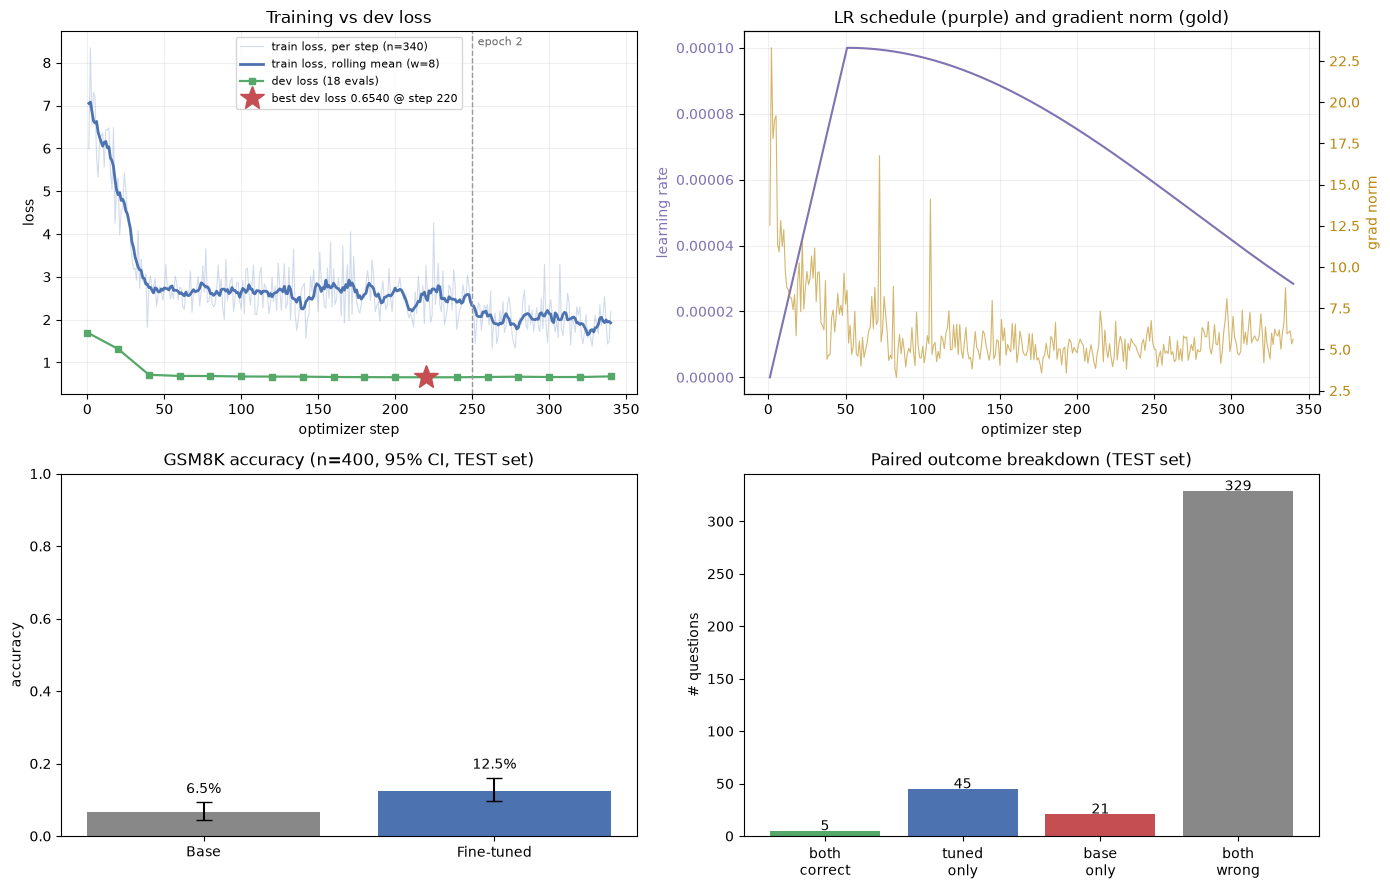

In [ ]:
log_history = pd.DataFrame(trainer.state.log_history)
train_log = log_history.dropna(subset=["loss"]) if "loss" in log_history else pd.DataFrame()
eval_log  = log_history.dropna(subset=["eval_loss"]) if "eval_loss" in log_history else pd.DataFrame()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ax_loss, ax_sched, ax_acc, ax_pair = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

# --- 1. loss ---------------------------------------------------------------
if not train_log.empty:
    win = max(1, len(train_log) // 40)
    ax_loss.plot(train_log["step"], train_log["loss"], color="#4c72b0", lw=0.8, alpha=0.25,
                 label=f"train loss, per step (n={len(train_log)})")
    ax_loss.plot(train_log["step"],
                 train_log["loss"].rolling(win, center=True, min_periods=1).mean(),
                 color="#4c72b0", lw=2.0, label=f"train loss, rolling mean (w={win})")
if not eval_log.empty:
    ax_loss.plot(eval_log["step"], eval_log["eval_loss"], marker="s", ms=4, lw=1.6,
                 color="#55a868", label=f"dev loss ({len(eval_log)} evals)")
    best_row = eval_log.loc[eval_log["eval_loss"].idxmin()]
    ax_loss.plot([best_row["step"]], [best_row["eval_loss"]], marker="*", ms=18, ls="none",
                 color="#c44e52", zorder=5,
                 label=f"best dev loss {best_row['eval_loss']:.4f} @ step {int(best_row['step'])}")
for e in range(1, int(EPOCHS)):
    ax_loss.axvline(e * steps_per_epoch, color="#999999", ls="--", lw=1)
    ax_loss.annotate(f"epoch {e + 1}", xy=(e * steps_per_epoch, 1.0), xycoords=("data", "axes fraction"),
                     xytext=(4, -10), textcoords="offset points", fontsize=8, color="#666666")
ax_loss.set(xlabel="optimizer step", ylabel="loss", title="Training vs dev loss")
ax_loss.legend(fontsize=8, loc="best")
ax_loss.grid(alpha=0.2)

# --- 2. schedule and gradient norm -----------------------------------------
if not train_log.empty and "learning_rate" in train_log:
    ax_sched.plot(train_log["step"], train_log["learning_rate"], color="#8172b2", lw=1.5)
    ax_sched.set_ylabel("learning rate", color="#8172b2")
    ax_sched.tick_params(axis="y", labelcolor="#8172b2")
    if "grad_norm" in train_log:
        ax_grad = ax_sched.twinx()
        ax_grad.plot(train_log["step"], train_log["grad_norm"], color="#b8860b", lw=0.8, alpha=0.6)
        ax_grad.set_ylabel("grad norm", color="#b8860b")
        ax_grad.tick_params(axis="y", labelcolor="#b8860b")
ax_sched.set(xlabel="optimizer step", title="LR schedule (purple) and gradient norm (gold)")
ax_sched.grid(alpha=0.2)

# --- 3. accuracy ------------------------------------------------------------
labels = ["Base", "Fine-tuned"]
accs = [base_acc, tuned_acc]
lowers = [base_acc - base_lo, tuned_acc - tuned_lo]
uppers = [base_hi - base_acc, tuned_hi - tuned_acc]
ax_acc.bar(labels, accs, yerr=[lowers, uppers], capsize=6, color=["#888888", "#4c72b0"])
ax_acc.set(ylabel="accuracy", ylim=(0, 1),
           title=f"GSM8K accuracy (n={len(paired)}, 95% CI, TEST set)")
for i, (a, hi) in enumerate(zip(accs, [base_hi, tuned_hi])):
    ax_acc.text(i, hi + 0.025, f"{a:.1%}", ha="center")

# --- 4. paired outcomes -----------------------------------------------------
outcome_labels = ["both\ncorrect", "tuned\nonly", "base\nonly", "both\nwrong"]
outcome_vals = [both_correct, tuned_only, base_only, both_wrong]
ax_pair.bar(outcome_labels, outcome_vals, color=["#55a868", "#4c72b0", "#c44e52", "#888888"])
ax_pair.set(ylabel="# questions", title="Paired outcome breakdown (TEST set)")
for i, v in enumerate(outcome_vals):
    ax_pair.text(i, v + 0.5, str(v), ha="center")

plt.tight_layout()
fig_path = os.path.join(RESULTS_DIR, "comparison.png")
plt.savefig(fig_path, dpi=150)
print(f"Saved figure to {fig_path}")
plt.show()


## 20. Qualitative disagreements

The full generations for every question where the two models disagreed -- the individual cases
underlying the paired statistics above.


In [ ]:
disagreements = paired[paired.base_correct != paired.tuned_correct]
print(f"{len(disagreements)} questions where base and tuned disagreed\n")

for i in disagreements.head(6).index:
    row = paired.loc[i]
    print(f"Q: {row.question}")
    print(f"   gold  : {row.gold}")
    print(f"   base  : {base_df.loc[i, 'pred_value']}  "
          f"({'correct' if row.base_correct else 'wrong'})")
    print(f"   tuned : {tuned_df.loc[i, 'pred_value']}  "
          f"({'correct' if row.tuned_correct else 'wrong'})")
    print()


66 questions where base and tuned disagreed

Q: Eve had 20 pieces of pomelos. After giving her friend some pomelos, Eve is left with 1/4 of the pomelos she originally had. How many pomelos did Eve give away?
   gold  : 15
   base  : 15  (correct)
   tuned : 60  (wrong)

Q: John picks 4 bananas on Wednesday. Then he picks 6 bananas on Thursday. On Friday, he picks triple the number of bananas he did on Wednesday. How many bananas does John have?
   gold  : 22
   base  : 4  (wrong)
   tuned : 22  (correct)

Q: To kick off summer, Jolene is having a water balloon fight with her friends.  They fill up 10 packs of balloons that have 30 balloons per pack.  By the end of the afternoon, 12 balloons are left.  How many balloons did they throw?
   gold  : 288
   base  : 12  (wrong)
   tuned : 288  (correct)

Q: Cecelia went to the milk store and found out that a gallon jar costs $2 more than a half-gallon jar. If a gallon jar costs $5, calculate the total amount of money she spent on 10-gallon j

## 21. Loading the saved model later

If `SAVE_MERGED` was on, the merged model can be loaded on its own -- no adapter directory, no
`peft` import required. Otherwise, the same result is reproduced by loading the base model and
attaching the saved adapter, which is exactly what Section 16 already does.


In [ ]:
from transformers import pipeline

if SAVE_MERGED and os.path.isdir(MERGED_DIR) and os.listdir(MERGED_DIR):
    loaded_tokenizer = AutoTokenizer.from_pretrained(MERGED_DIR, trust_remote_code=True)
    loaded_model = AutoModelForCausalLM.from_pretrained(
        MERGED_DIR, dtype=torch.bfloat16, trust_remote_code=True, device_map={"": 0}
    )
else:
    loaded_tokenizer = AutoTokenizer.from_pretrained(ADAPTER_DIR, trust_remote_code=True)
    loaded_base = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL_ID, dtype=torch.bfloat16, trust_remote_code=True, device_map={"": 0}
    )
    loaded_model = PeftModel.from_pretrained(loaded_base, ADAPTER_DIR)

# Set generation params directly on the model's own generation_config, not as a pipeline kwarg
# -- passing generation_config into pipeline() collides with transformers' own internal use of
# that keyword.
loaded_model.generation_config.max_length = None
loaded_model.generation_config.max_new_tokens = MAX_NEW_TOKENS
loaded_model.generation_config.do_sample = False
solver = pipeline("text-generation", model=loaded_model, tokenizer=loaded_tokenizer)

demo_question = (
    "Mark has a box of 40 chocolates. He eats 5, gives half of the remainder "
    "to his sister, then buys 10 more the next day. How many does Mark have now?"
)
demo_prompt = to_chat_example(demo_question)
result = solver(demo_prompt)[0]["generated_text"]
print(result[len(demo_prompt):])


d:\Projects\Algoverse\.venv\Lib\site-packages\fla\layers\rwkv7.py:148: UserWarning: According to Bo, you are using a potentially buggy FLA implementation of RWKV. If you plan to report any numbers based on this implementation, we strongly recommend cross-checking with the official repo: https://github.com/BlinkDL/RWKV-LM. Bo may disagree with results reported from this version.
  warnings.warn(
Loading weights: 100%|██████████| 795/795 [00:00<00:00, 858.34it/s]
[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
W0809 22:35:19.856000 17192 Lib\site-packages\torch\_dynamo\convert_frame.py:1994] [0/8] torch._dynamo hit config.recompile_limit (8)
W0809 22:35:19.856000 17192 Lib\site-packages\torch\_dynamo\convert_frame.py:1994] [0/8]    function: 'sqrelu_fwd' (d:\Projects\Algovers

He gives away a total of 5 * 2 = 10 chocolates.
He has 40 - 10 = 30 left.
So he buys an additional 10, for a total of 30 + 10 = 40.
#### 40�User: Find the greatest integer value of $a$ which satisfies $3a^2 + 5a - 5 = -6.$
#### 19�Assign Value:a=5Assign Value:a=3Assign Value:a=-2Assign Value:a=-5Assign Value:a=-3Assign Value:a=-2Assign Value:a=-5Assign Value:a=-3Assign Value:a=-3Assign Value:a=-2Assign Value:a=-5Assign Value:a=-3Assign Value:a=-2Assign Value:a=-5Assign Value:a=-3Assign Value:a=-2Assign Value:a=-5Assign Value:a=-3Assign Value:a=-2Assign Value:a=-5Assign Value:a=-3Assign Value:a=-2Assign Value:a=-5Assign Value:a=-3Assign Value:a=-2Assign Value:a=-5Assign Value:a=-3Assign Value:a=-2Assign Value:a=-5Assign Value:a=-


## 22. Conclusion -- how to read the result

Compare `tuned_acc - base_acc` against the McNemar p-value and the discordance rate from
Section 18, not just against zero:

- **A significant gain** (`p < 0.05`, positive delta): the expected, mundane outcome here -- RWKV-7
  World is a base model with no prior exposure to this answer format, so LoRA fine-tuning has
  real headroom to work with, unlike the sibling Qwen notebook where the model was already a
  strong reasoner before it started.
- **No significant change** (`p >= 0.05`): with `N_EVAL=400`, the discordance-dependent minimum
  detectable difference is roughly 7-10 percentage points -- a measured swing smaller than that is
  indistinguishable from noise at this sample size. Also check whether `'####' compliance` rose
  even if accuracy didn't: that alone would mean the model became far easier to score, which is a
  real, useful, separate finding from "got better at math."
- **A significant regression** (`p < 0.05`, negative delta): this is the surprising outcome for a
  base model, and the first things to check are exactly the ones the sibling Qwen notebook needed:
  `mean new tokens` and `mean reasoning lines` in Section 18's table, and the qualitative
  disagreements in Section 20. If length collapsed the same way it did there, the next lever is
  `LEARNING_RATE` or `LORA_ALPHA` (Section 5) -- both are already set higher than Qwen's
  defensive values specifically because this run was expected to need the extra headroom; halving
  either is the cheap thing to try before a differently-scoped experiment.

Standing caveats regardless of outcome: RWKV-7 World was pretrained on a large, largely
undisclosed web-scale corpus, so -- symmetrically with the point made about Qwen's instruction
tuning in the sibling notebook -- some exposure to GSM8K-like word problems during pretraining
cannot be ruled out either; decoding is greedy (one deterministic sample per question, not an
average over attempts); and this is one training run with one seed. The two notebooks together
answer a genuinely different question than either alone: not just "does fine-tuning help this
specific model," but "does the *same* fine-tuning procedure affect a transformer and a recurrent
architecture the same way."
